# GLIMMER v2: Does This Actually Matter Clinically?

Notebooks 02 and 03 measured v0 and v1 with RMSE and MAE, plain average error. Those
numbers don't directly answer the question a clinician would actually ask: would trusting
this prediction ever lead to a dangerous decision? This notebook adds the two metrics the
paper uses to answer that directly.

**Event detection (precision/recall/F1):** treat every 5-minute reading as either
dysglycemic (below 70 or above 180) or not, for both the true value and the prediction,
and score it like a detector. High recall means the model rarely misses a real danger
moment. High precision means it doesn't cry wolf too often either.

**Clarke Error Grid:** a standard clinical tool that classifies every (actual, predicted)
pair into one of five zones by how much clinical harm a wrong prediction would cause, not
just how far off the number was. Zone A is safe. Zone D means a real danger moment got
predicted as normal, a missed warning. Zone E means the prediction was on the completely
wrong side (predicted high when actually low, or the reverse), the worst case.

**Status: code is written and function-tested, but the actual 25-subject training runs
below have not been executed yet.** They take about 7-8 minutes (same v0 and v1 runs as
notebook 03). Flagging that clearly before running it for real.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting, synthetic
from azt1d import reference as ref
from azt1d.glimmer.train import run_with_checkpoints
from azt1d.glimmer.clinical import dysglycemia_event_metrics, clarke_zone_percentages, draw_clarke_grid

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Load data


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROCESSED_DIR / "synthetic"

has_real_data = loading.find_dataset_zip(RAW_DIR) is not None or bool(loading.discover_subject_files(RAW_DIR))

if has_real_data:
    print("Found real AZT1D data in data/raw/ -- loading it.")
    df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
    USING_SYNTHETIC = False
else:
    print("No real dataset found in data/raw/ yet -- using synthetic placeholder data.")
    if not any(SYNTHETIC_DIR.glob("*.csv")):
        synthetic.write_synthetic_csvs(SYNTHETIC_DIR)
    df = loading.load_all_subjects(SYNTHETIC_DIR)
    USING_SYNTHETIC = True

print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects.")


Found real AZT1D data in data/raw/ -- loading it.


Loaded 300,923 rows across 25 subjects.


## 2. Train v0 and v1 across all 25 subjects

Same as notebook 03: one CNN-LSTM per person, plain loss for v0 and the paper's fixed
weighted loss for v1. Checkpointed to `data/processed/checkpoints/` under a name shared
with notebooks 03 and 05, so this only actually trains once; every other notebook that
needs the same v0/v1 CNN-LSTM models loads them from disk instead of retraining. Safe to
interrupt, rerunning this cell picks up wherever it left off.


In [3]:
GLIMMER_WEIGHTS = ref.GLIMMER_PAPER_WEIGHTS["cnn_lstm"]
CHECKPOINT_DIR = PROCESSED_DIR / "checkpoints"

summary_v0, results_v0 = run_with_checkpoints(df, CHECKPOINT_DIR / "cnn_lstm_v0", epochs=30, region_weights=None)
summary_v1, results_v1 = run_with_checkpoints(df, CHECKPOINT_DIR / "cnn_lstm_v1", epochs=30, region_weights=GLIMMER_WEIGHTS)

print(f"v0: RMSE {summary_v0['rmse'].mean():.2f} mg/dL   MAE {summary_v0['mae'].mean():.2f} mg/dL")
print(f"v1: RMSE {summary_v1['rmse'].mean():.2f} mg/dL   MAE {summary_v1['mae'].mean():.2f} mg/dL")


Subject 1: trained and checkpointed (RMSE=25.29 mg/dL)


Subject 2: trained and checkpointed (RMSE=36.73 mg/dL)


Subject 3: trained and checkpointed (RMSE=24.96 mg/dL)


Subject 4: trained and checkpointed (RMSE=32.12 mg/dL)


Subject 5: trained and checkpointed (RMSE=26.97 mg/dL)


...

Subject 21: trained and checkpointed (RMSE=54.91 mg/dL)


Subject 22: trained and checkpointed (RMSE=41.49 mg/dL)


Subject 23: trained and checkpointed (RMSE=41.39 mg/dL)


Subject 24: trained and checkpointed (RMSE=34.63 mg/dL)


Subject 25: trained and checkpointed (RMSE=46.62 mg/dL)
v0: RMSE 31.54 mg/dL   MAE 24.01 mg/dL
v1: RMSE 41.18 mg/dL   MAE 32.73 mg/dL


## 3. Event detection: does v1 catch more real danger moments?

This is the metric that should move if the weighted loss is doing its job, even the
notebook 03 result (worse overall RMSE) doesn't rule out this improving.


In [4]:
def cohort_event_metrics(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return dysglycemia_event_metrics(all_true, all_pred)

metrics_v0 = cohort_event_metrics(results_v0)
metrics_v1 = cohort_event_metrics(results_v1)

comparison = pd.DataFrame({"v0": metrics_v0, "v1": metrics_v1}).loc[["precision", "recall", "f1"]]
comparison.round(3)


,v0,v1
precision,0.678,0.373
recall,0.507,0.722
f1,0.580,0.491


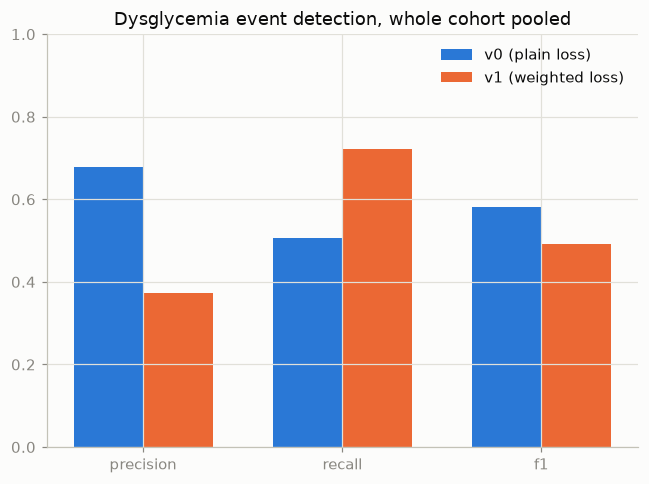

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(3)
width = 0.35
labels = ["precision", "recall", "f1"]
ax.bar(x - width/2, comparison.loc[labels, "v0"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, comparison.loc[labels, "v1"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Dysglycemia event detection, whole cohort pooled"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. Clarke Error Grid: how often would a wrong prediction actually matter?

One person's scatter first, to see the shape directly, then the zone breakdown across
everyone.


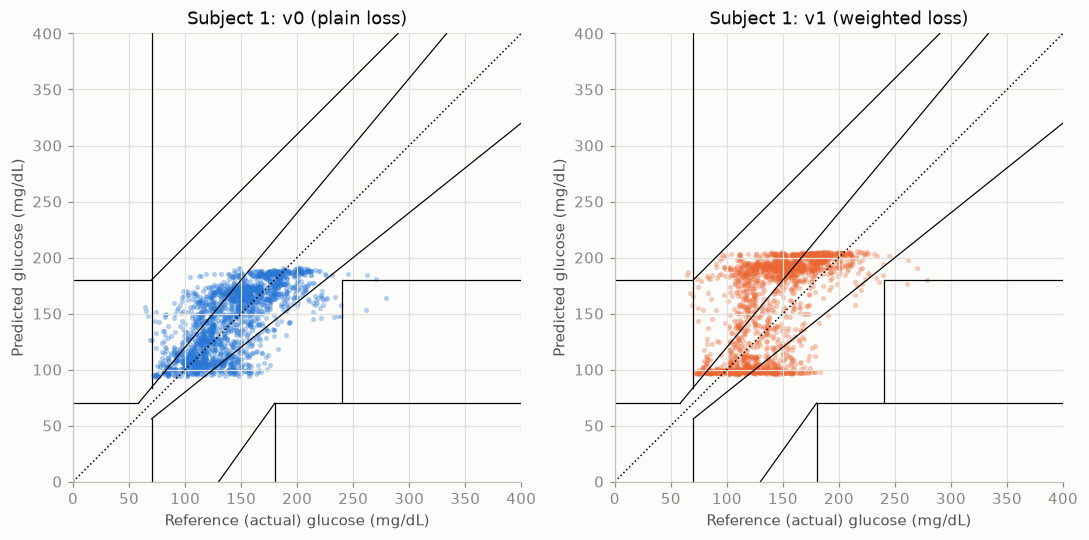

In [6]:
example_id = sorted(results_v0.keys())[0]
r0, r1 = results_v0[example_id], results_v1[example_id]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw_clarke_grid(axes[0], r0.y_test, r0.y_pred, color=plotting.CATEGORICAL[0])
axes[0].set_title(f"Subject {example_id}: v0 (plain loss)")
draw_clarke_grid(axes[1], r1.y_test, r1.y_pred, color=plotting.CATEGORICAL[1])
axes[1].set_title(f"Subject {example_id}: v1 (weighted loss)")
fig.tight_layout()
plt.show()


In [7]:
def cohort_zone_percentages(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return clarke_zone_percentages(all_true, all_pred)

zones_v0 = cohort_zone_percentages(results_v0)
zones_v1 = cohort_zone_percentages(results_v1)

zone_table = pd.DataFrame({"v0": zones_v0, "v1": zones_v1}).reindex(["A", "B", "C", "D", "E"])
zone_table["change"] = zone_table["v1"] - zone_table["v0"]
zone_table.round(2)


,v0,v1,change
A,67.95,51.50,-16.45
B,29.62,46.70,17.09
C,0.05,0.25,0.20
D,2.37,1.33,-1.03
E,0.01,0.21,0.19


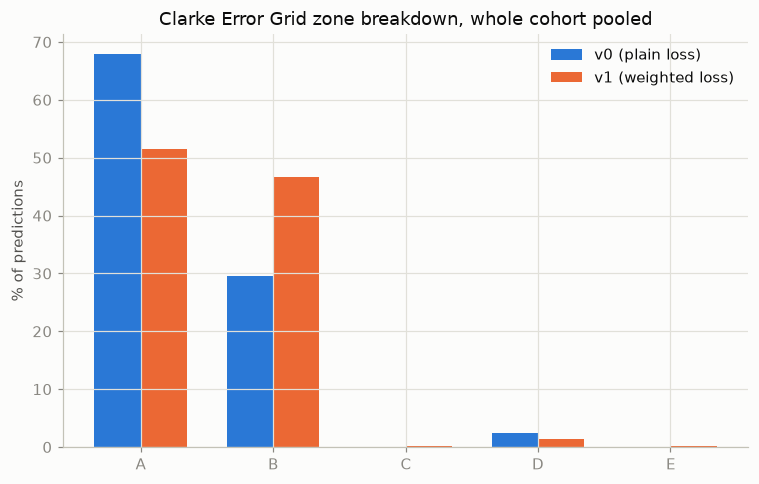

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
zones = ["A", "B", "C", "D", "E"]
x = np.arange(len(zones))
width = 0.35
ax.bar(x - width/2, zone_table.loc[zones, "v0"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, zone_table.loc[zones, "v1"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(zones)
ax.set_ylabel("% of predictions")
ax.set_title("Clarke Error Grid zone breakdown, whole cohort pooled"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. What this adds to the v1 story

Notebook 03 found v1's weighted loss helps in the hypo/hyper regions specifically but
hurts overall RMSE/MAE, on average across all readings. The event detection and Clarke
Error Grid numbers above test a related but different question: not how close the
numbers were, but how often a mistake would have actually mattered. Whether that picture
agrees with or complicates the RMSE-based story is worth reading directly off the tables
above once this has actually been run, rather than assumed ahead of time here.
